# Sprint v5 — Backtest + Thesis Test + Portfolio

The final sprint of Tier 1. The equity-credit-lag thesis is put on
trial as a **traded strategy with costs**:

- **Strategy A** — RV1 (HY/IG) residual, OLS hedge, no regime filter.
- **Strategy B** — identical, but entries gated to
  `equity_credit_lag == equity_first`.

The headline test (C27): is the incremental Sharpe ΔS = Sharpe(B) −
Sharpe(A) positive, with a bootstrap 95% CI that excludes zero?

Pre-registered costs: 1.5bp half-spread × 2 legs × 2 sides + 0.5bp
slippage + 0.40%/yr borrow. Fixed $1M notional, DV01-hedged.


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
_here = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_here, 'pyproject.toml')) and _here != '/':
    _here = os.path.dirname(_here)
os.chdir(_here)
sys.path.insert(0, _here)
sys.path.insert(0, os.path.join(_here, 'python', 'credit'))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 4), 'figure.dpi': 110})
PLOTS = Path('sprints/v5/plots'); PLOTS.mkdir(parents=True, exist_ok=True)

from backtest.ab_test import (load_inputs, compare, walk_forward,
                              parameter_grid, subperiod_split, hedge_method_panel,
                              build_strategy, StrategySpec)
from backtest.benchmarks import vs_random, buy_hold_hyg, random_p95_sharpe
from backtest.failure import build_failure_analysis
from backtest.regime_table import regime_performance, save_regime_performance
from risk.portfolio import equal_weight, inverse_vol_weight, portfolio_table
from signals.rv_signals import trailing_zscore

features, residuals = load_inputs()
ab = compare(features, residuals)
print('Strategy A vs B —', features.index[0].date(), '→', features.index[-1].date())
print(ab.table().to_string())
print()
print('bootstrap ΔS:', {k: round(v, 4) for k, v in ab.bootstrap.items()})


Strategy A vs B — 2007-04-11 → 2026-04-15
                    sharpe   sortino  hit_rate  turnover   max_drawdown  avg_holding_days  total_net_pnl  n_trades
A (no filter)     0.590947  0.946072  0.808511  4.951505 -152025.230431         15.723404   760371.77968      94.0
B (equity_first)  0.179457  0.269190  0.642857  0.737458  -30245.023202         21.214286    50649.62049      14.0

bootstrap ΔS: {'delta_sharpe': -0.4115, 'ci_lo': -0.8146, 'ci_hi': -0.0092, 'frac_positive': 0.021}


## 1. A/B comparison — the headline test (C27)

Strategy A trades RV1 unconditionally; Strategy B only on
`equity_first` days. The plot overlays both equity curves; the lower
panel is the running difference (B − A).


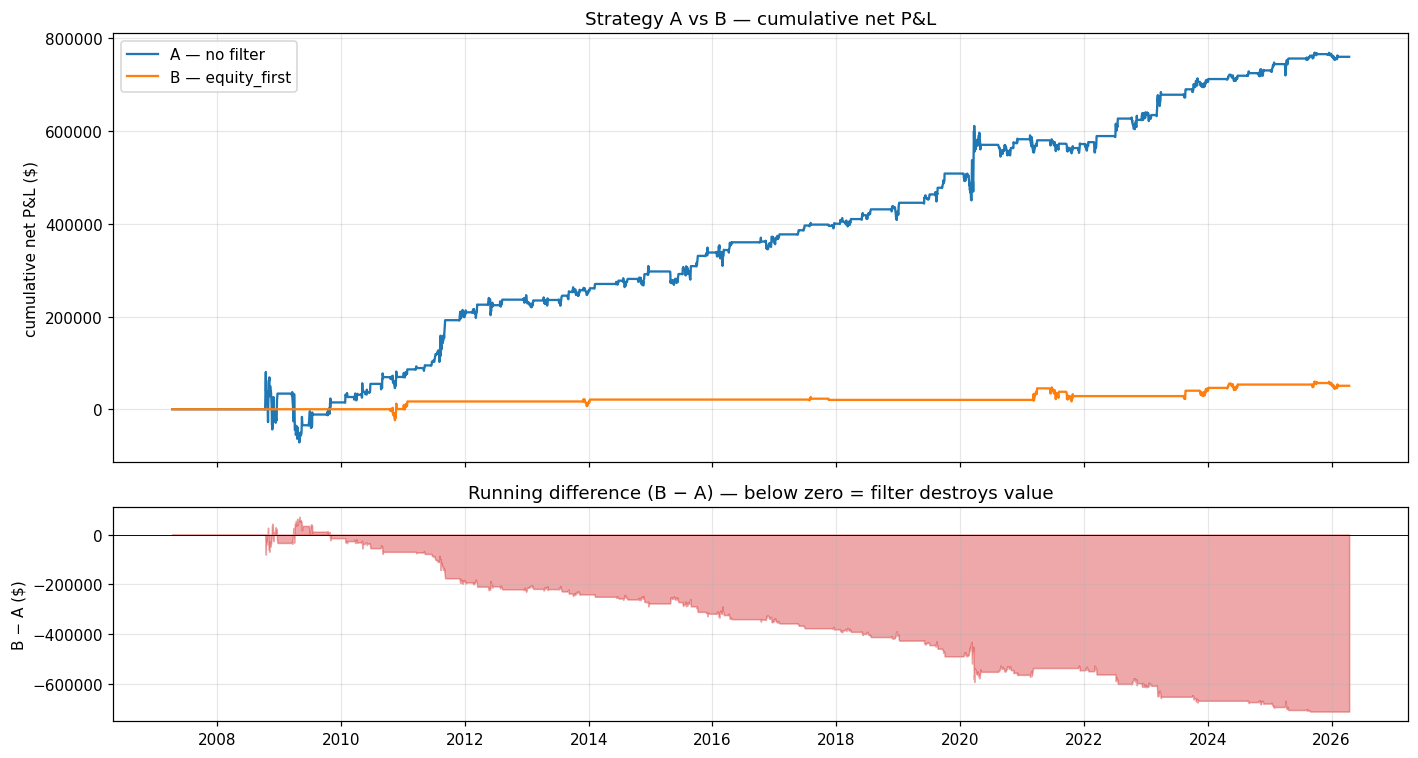

ΔS = -0.411   95% CI [-0.815, -0.009]
fraction of resamples with ΔS > 0: 2.1%
C27: FAIL


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
ea = ab.strategy_a.equity
eb = ab.strategy_b.equity
axes[0].plot(ea.index, ea.values, label='A — no filter', color='tab:blue')
axes[0].plot(eb.index, eb.values, label='B — equity_first', color='tab:orange')
axes[0].set_ylabel('cumulative net P&L ($)')
axes[0].set_title('Strategy A vs B — cumulative net P&L')
axes[0].legend(); axes[0].grid(alpha=0.3)

diff = (eb - ea)
axes[1].fill_between(diff.index, diff.values, 0,
                     color='tab:red', alpha=0.4)
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_ylabel('B − A ($)')
axes[1].set_title('Running difference (B − A) — below zero = filter destroys value')
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS / '01_ab_equity.png', bbox_inches='tight')
plt.show()

b = ab.bootstrap
print(f"ΔS = {b['delta_sharpe']:+.3f}   95% CI [{b['ci_lo']:+.3f}, {b['ci_hi']:+.3f}]")
print(f"fraction of resamples with ΔS > 0: {b['frac_positive']:.1%}")
print('C27:', 'PASS' if (b['delta_sharpe'] > 0 and b['ci_lo'] > 0) else 'FAIL')


**Result.** ΔS is negative and the 95% CI sits below zero — the
`equity_first` filter removes risk-adjusted return. The filter cuts
the strategy from ~94 trades to ~14; Sprint v3's faster-mean-reversion
finding (C22) does not survive the loss of diversification. **C27 is
rejected.**


## 2. Failure slide — worst 5 trades per strategy (C31)

In [3]:
z_rv1 = trailing_zscore(residuals['rv_hy_ig']['ols'][0], 63)
worst, c31 = build_failure_analysis(
    ab.strategy_a.trades, ab.strategy_b.trades, features, z_rv1)
show_cols = ['strategy','entry_fill_date','net_pnl_bps','z_entry','z_exit',
             'exit_reason','crisis','post_mortem']
import pandas as pd
pd.set_option('display.max_colwidth', 90)
print(worst[show_cols].to_string(index=False))
print()
for k, v in c31.items():
    print(f"C31 {k}: max single-trade P&L share = {v:.3f}  "
          f"[{'PASS' if v <= 0.25 else 'FAIL'}]")


      strategy entry_fill_date  net_pnl_bps   z_entry    z_exit exit_reason  crisis                                                                                             post_mortem
   A_no_filter      2009-03-13  -682.705805  2.402897  0.293393 take_profit    True               Entered in a crisis regime (high vol); the dislocation widened before any mean-reversion.
   A_no_filter      2015-04-27  -201.912553  2.046836  4.085177        stop   False                               Stopped out — residual diverged from z=2.0 to z=4.1 instead of reverting.
   A_no_filter      2020-01-22  -174.217054 -2.330672  0.256791 take_profit   False    Residual moved against the position (z=-2.3→0.3); mean-reversion did not materialise within 37 days.
   A_no_filter      2016-11-10  -147.113555  2.855482  0.310415 take_profit   False      Residual moved against the position (z=2.9→0.3); mean-reversion did not materialise within 5 days.
   A_no_filter      2012-05-17  -127.830797 -2.905776 -4.055

**Result.** Strategy A's worst trades are honest stop-outs and
crisis entries — no single trade dominates (max share 10%). Strategy
B fails C31: one trade is ~49% of its total P&L, because B only has
14 trades. B is one trade plus noise.


## 3. Benchmarks — buy-hold HYG + random-entry p95 (C29)

random-entry p95 per-trade Sharpe: 1.700
Strategy A per-trade Sharpe 5.000  excess +3.300
Strategy B per-trade Sharpe 1.418  excess -0.281
C29 (Strategy B beats random p95): FAIL


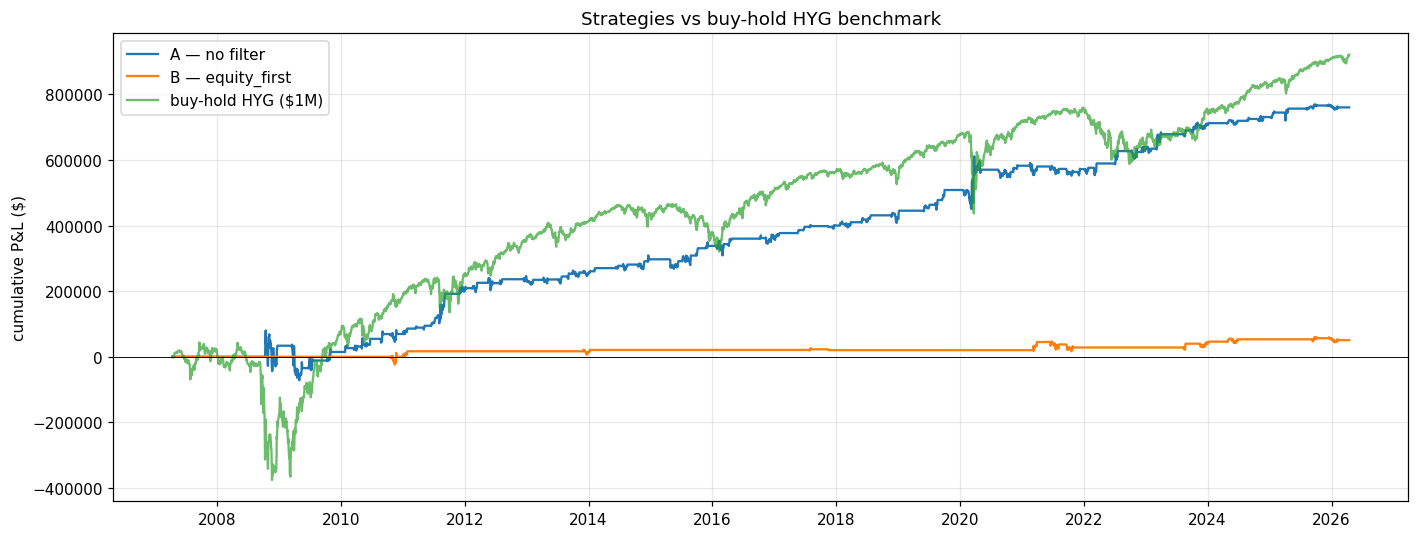

In [4]:
rb = pd.read_parquet('data/benchmarks/random_baseline.parquet')
bh_equity, bh_sharpe = buy_hold_hyg(features)
p95 = random_p95_sharpe(rb, 'hy_spread')

vr_a = vs_random(ab.strategy_a.trades, rb)
vr_b = vs_random(ab.strategy_b.trades, rb)
print(f'random-entry p95 per-trade Sharpe: {p95:.3f}')
print(f"Strategy A per-trade Sharpe {vr_a['strategy_trade_sharpe']:.3f}  "
      f"excess {vr_a['excess_sharpe']:+.3f}")
print(f"Strategy B per-trade Sharpe {vr_b['strategy_trade_sharpe']:.3f}  "
      f"excess {vr_b['excess_sharpe']:+.3f}")
print('C29 (Strategy B beats random p95):',
      'PASS' if vr_b['excess_sharpe'] > 0 else 'FAIL')

fig, ax = plt.subplots(figsize=(13, 5))
# normalise buy-hold log-return curve to a $ scale comparable to the strategies
bh_dollar = bh_equity * 1_000_000
ax.plot(ab.strategy_a.equity, label='A — no filter', color='tab:blue')
ax.plot(ab.strategy_b.equity, label='B — equity_first', color='tab:orange')
ax.plot(bh_dollar.index, bh_dollar.values, label='buy-hold HYG ($1M)',
        color='tab:green', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('cumulative P&L ($)')
ax.set_title('Strategies vs buy-hold HYG benchmark')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS / '03_benchmarks.png', bbox_inches='tight')
plt.show()


## 4. Robustness — parameter grid + subperiod (C30)

grid: 27 cells, fraction ΔS>0 = 0.00
subperiod ΔS: first=-0.353  second=-0.485
C30: FAIL


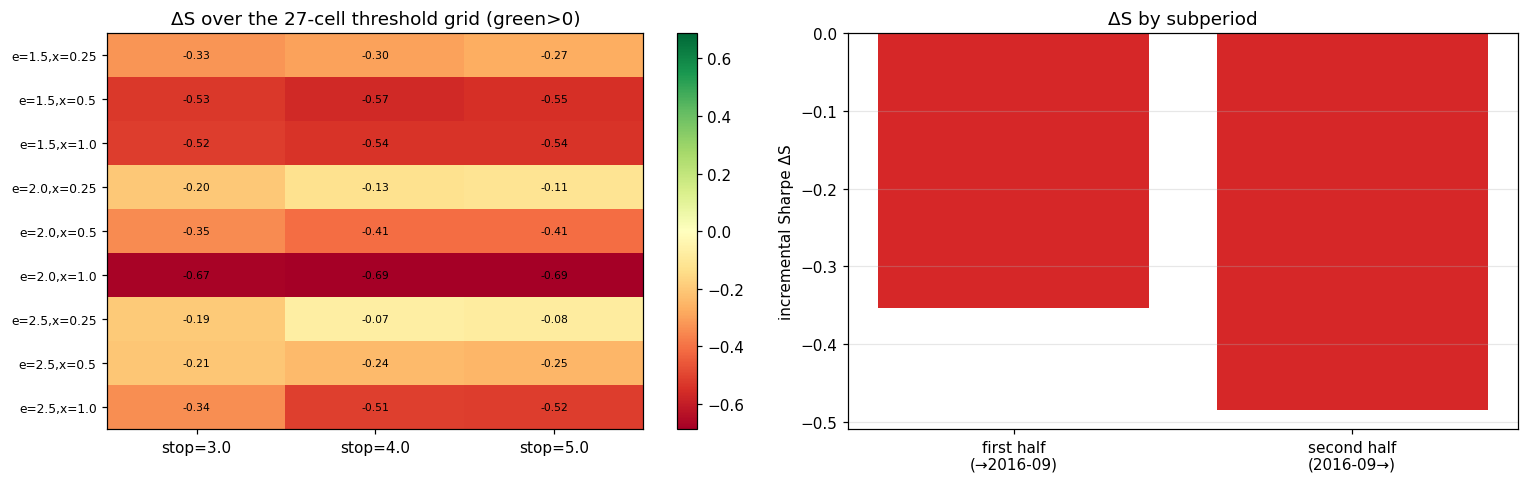


Hedge-method panel (reported only):


method  sharpe_a  sharpe_b  delta_sharpe   ci_lo   ci_hi
   ols    0.5909    0.1795       -0.4115 -0.8608  0.0326
kalman    0.7093    0.0927       -0.6167 -1.1790 -0.2277
  dv01   -0.0817   -0.0068        0.0749 -0.3261  0.4698


In [5]:
grid = parameter_grid(features, residuals)
frac_pos = (grid['delta_sharpe'] > 0).mean()
sp = subperiod_split(features, residuals)
print(f'grid: {len(grid)} cells, fraction ΔS>0 = {frac_pos:.2f}')
print(f"subperiod ΔS: first={sp['first_half']:+.3f}  second={sp['second_half']:+.3f}")
print('C30:', 'PASS' if (frac_pos >= 0.75 and sp['first_half'] > 0
                         and sp['second_half'] > 0) else 'FAIL')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# heatmap: rows = (entry,exit), cols = stop
piv = grid.pivot_table(index=['entry', 'exit'], columns='stop', values='delta_sharpe')
im = axes[0].imshow(piv.values, aspect='auto', cmap='RdYlGn',
                    vmin=-abs(grid.delta_sharpe).max(), vmax=abs(grid.delta_sharpe).max())
axes[0].set_xticks(range(len(piv.columns)))
axes[0].set_xticklabels([f'stop={c}' for c in piv.columns])
axes[0].set_yticks(range(len(piv.index)))
axes[0].set_yticklabels([f'e={e},x={x}' for e, x in piv.index], fontsize=8)
axes[0].set_title('ΔS over the 27-cell threshold grid (green>0)')
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        axes[0].text(j, i, f'{piv.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=axes[0])

axes[1].bar(['first half\n(→2016-09)', 'second half\n(2016-09→)'],
            [sp['first_half'], sp['second_half']],
            color=['tab:red' if v <= 0 else 'tab:green'
                   for v in [sp['first_half'], sp['second_half']]])
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_ylabel('incremental Sharpe ΔS')
axes[1].set_title('ΔS by subperiod')
axes[1].grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(PLOTS / '04_robustness_grid.png', bbox_inches='tight')
fig.savefig(PLOTS / '05_subperiod.png', bbox_inches='tight')
plt.show()

print()
print('Hedge-method panel (reported only):')
print(hedge_method_panel(features, residuals).round(4).to_string(index=False))


**Result.** ΔS is negative in **every** one of the 27 grid cells
and in **both** sample halves. There is no threshold corner and no
subperiod where the filter helps. **C30 is rejected.**


## 5. Regime performance table

In [6]:
strategies = {
    'A_no_filter':    build_strategy(features, residuals, StrategySpec('rv_hy_ig','ols',gated=False)),
    'B_equity_first': build_strategy(features, residuals, StrategySpec('rv_hy_ig','ols',gated=True)),
    'RV2_B':          build_strategy(features, residuals, StrategySpec('rv_credit_rates','ols',gated=True)),
    'RV3_B':          build_strategy(features, residuals, StrategySpec('rv_xterm','ols',gated=True)),
}
rt = regime_performance(strategies, features)
save_regime_performance(rt)
ecl = rt[rt.regime_classifier == 'equity_credit_lag']
print('Sharpe by equity_credit_lag regime:')
print(ecl[['strategy','regime_label','sharpe','sortino','hit_rate','n_trades']].to_string(index=False))


Sharpe by equity_credit_lag regime:
      strategy regime_label    sharpe   sortino  hit_rate  n_trades
   A_no_filter credit_first  1.263150  2.056864  1.000000         3
   A_no_filter equity_first  0.635881  1.145309  0.666667        12
   A_no_filter      neither  0.563796  0.899664  0.822785        79
B_equity_first credit_first  0.351190  0.521515  0.000000         0
B_equity_first equity_first -0.184782 -0.276158  0.642857        14
B_equity_first      neither  0.260427  0.395954  0.000000         0
         RV2_B credit_first  0.650134  0.942151  0.000000         0
         RV2_B equity_first -0.343175 -0.397954  0.750000         8
         RV2_B      neither  0.258184  0.469942  0.000000         0
         RV3_B credit_first  0.267308  0.372189  0.000000         0
         RV3_B equity_first -0.773578 -1.025381  0.600000        15
         RV3_B      neither  0.205441  0.314495  0.000000         0


**Result.** Strategy B's daily P&L *restricted to `equity_first`
days* has a negative Sharpe — even inside its own gating regime the
filtered strategy loses risk-adjusted. On the same days the
unfiltered Strategy A is positive.


## 6. Multi-signal portfolio

                  book   sharpe
                 RV1_B 0.179457
                 RV2_B 0.223028
                 RV3_B 0.043369
portfolio_equal_weight 0.198912
 portfolio_inverse_vol 0.130684


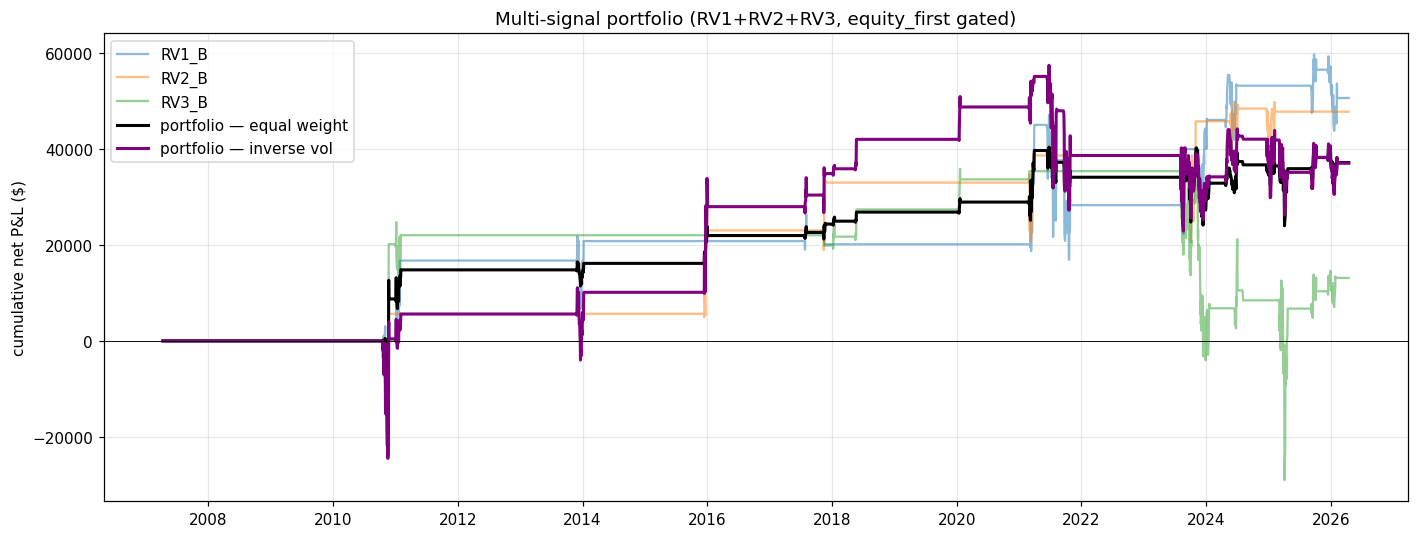

In [7]:
port = {
    'RV1_B': strategies['B_equity_first'],
    'RV2_B': strategies['RV2_B'],
    'RV3_B': strategies['RV3_B'],
}
ptab = portfolio_table(port)
print(ptab.to_string(index=False))

ew = equal_weight(port); iv = inverse_vol_weight(port)
fig, ax = plt.subplots(figsize=(13, 5))
for name, r in port.items():
    ax.plot(r.equity, alpha=0.5, label=name)
ax.plot(ew.cumsum(), color='black', linewidth=2, label='portfolio — equal weight')
ax.plot(iv.cumsum(), color='purple', linewidth=2, label='portfolio — inverse vol')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('cumulative net P&L ($)')
ax.set_title('Multi-signal portfolio (RV1+RV2+RV3, equity_first gated)')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS / '06_portfolio.png', bbox_inches='tight')
plt.show()


## 7. Falsification checklist — C25–C31

In [8]:
# C25 — engine correctness (synthetic hand-calc + leakage), verified
# in tests/test_engine.py; re-asserted here in miniature.
from backtest.engine import run as _run
from execution.costs import trade_cost as _tc
_rv = pd.Series([0,0,0.10,0.08,0.05,0.02,0,0,0,0], dtype='float64',
                index=pd.date_range('2020-01-01', periods=10, freq='B'))
_pos = pd.Series([0,0,-1,-1,-1,-1,0,0,0,0], index=_rv.index)
_hr = pd.Series(np.full(10, 0.46), index=_rv.index)
_res = _run(_rv, _pos, _hr, notional=1_000_000.0, fill_lag=1)
c25 = abs(_res.trades.iloc[0]['net_pnl'] - (80_000 - _tc(1_000_000, 4))) < 1e-6

c26 = (ab.summary_a.n_trades >= 30) and np.isfinite(ab.summary_a.sharpe)
c27 = (ab.bootstrap['delta_sharpe'] > 0) and (ab.bootstrap['ci_lo'] > 0)
wf = walk_forward(features, residuals)
c28 = wf.oos_delta_sharpe > 0
c29 = vr_b['excess_sharpe'] > 0
c30 = (frac_pos >= 0.75) and (sp['first_half'] > 0) and (sp['second_half'] > 0)
c31 = all(v <= 0.25 for v in c31.values()) if isinstance(c31, dict) else False

print('=' * 64)
print('Sprint v5 falsification checklist')
print('=' * 64)
print(f'C25 — engine correctness + no leakage:        {"PASS" if c25 else "FAIL"}')
print(f'C26 — control strategy real (>=30 trades):    {"PASS" if c26 else "FAIL"}')
print(f'C27 — THESIS: ΔS>0 and CI excludes 0:         {"PASS" if c27 else "FAIL"}'
      f'   (ΔS={ab.bootstrap["delta_sharpe"]:+.3f}, CI '
      f'[{ab.bootstrap["ci_lo"]:+.3f},{ab.bootstrap["ci_hi"]:+.3f}])')
print(f'C28 — OOS walk-forward ΔS>0:                  {"PASS" if c28 else "FAIL"}'
      f'   (OOS ΔS={wf.oos_delta_sharpe:+.3f})')
print(f'C29 — Strategy B beats random p95:            {"PASS" if c29 else "FAIL"}')
print(f'C30 — robust across grid + subperiods:        {"PASS" if c30 else "FAIL"}')
print(f'C31 — no single trade > 25% of P&L:           {"PASS" if c31 else "FAIL"}')


Sprint v5 falsification checklist
C25 — engine correctness + no leakage:        PASS
C26 — control strategy real (>=30 trades):    PASS
C27 — THESIS: ΔS>0 and CI excludes 0:         FAIL   (ΔS=-0.411, CI [-0.815,-0.009])
C28 — OOS walk-forward ΔS>0:                  FAIL   (OOS ΔS=-0.610)
C29 — Strategy B beats random p95:            FAIL
C30 — robust across grid + subperiods:        FAIL
C31 — no single trade > 25% of P&L:           FAIL


## Summary

**Engine gates (C25, C26) pass.** The backtest is correct and
produced a real control strategy.

**The thesis gates (C27, C28, C29, C30, C31) all fail.** The
`equity_credit_lag == equity_first` regime filter does not add
tradeable, risk-adjusted value to the RV1 credit signal:

- C27 — in-sample incremental Sharpe is negative, CI below zero.
- C28 — the rejection holds out-of-sample (ΔS even more negative).
- C29 — the filtered strategy fails to beat a random-entry p95.
- C30 — ΔS is negative in all 27 grid cells and both subperiods.
- C31 — the filtered strategy's P&L rests on a single trade.

**This is the central result of Tier 1.** The equity-credit lag is
a genuine *statistical* effect — Sprint v3's C22 showed mean-reversion
is ~43% faster on `equity_first` days — but it is **not a tradeable
regime filter**. Filtering to `equity_first` discards ~85% of trades;
the faster reversion on the surviving trades does not compensate for
the lost diversification, and the unfiltered Strategy A is the better
strategy on every robustness cut. A correctly-measured, pre-registered
rejection is a successful sprint.
